In [1]:
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = 'all'
from IPython.core.display import display, HTML
display(HTML("<style>.container { width:100% !important; }</style>"))
import warnings
warnings.filterwarnings(action='ignore') 

# Imports
import pandas as pd
import numpy as np
import seaborn as sns; sns.set()
import datetime
import matplotlib.pyplot as plt
%matplotlib inline
plt.rcParams['font.family']='Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False #한글 폰트 사용시 마이너스 폰트 깨짐 해결

In [2]:
path = r'D:\스마트 수입식품\관련자료\위해도분석모형\위해도 분석 관련자료\01.위해도 등급별 자료'

In [3]:
data = pd.read_excel(path + '/수산_추출자료(20.01~21.05).xlsx')

In [4]:
data.columns

Index(['년월', '접수번호', '식품1_수산2_축산3', '화주_인허가대장번호', '화주_인허가번호', '수입업체명', '국가',
       '국가명', '품목', '품목명', '제품명(영문)', '제품명(한글)', '위해도점수', '등급', '부적합여부',
       '부적합사유코드', '부적합사유명', '부적합통보내용', '무작위456선별유무', '대행사사업자번호', '대행업체명/신청인'],
      dtype='object')

In [5]:

selectec_cols = [0, 1, 7, 11, 12, 13, 14]
df = pd.read_excel(path + '/수산_추출자료(20.01~21.05).xlsx', usecols= selectec_cols)
df

,년월,접수번호,국가명,제품명(한글),위해도점수,등급,부적합여부
0,202105,202100279576,러시아,대게(활),2.121335e-02,2,적합
1,202105,202100324697,중국,마른다시마,6.700000e-08,9,적합
2,202105,202100318343,노르웨이,연어(냉장),2.121335e-02,2,적합
3,202105,202100281302,러시아,냉동임연수어,2.899931e-02,2,적합
4,202105,202100319831,미국,바닷가재(활),9.668111e-02,1,적합
...,...,...,...,...,...,...,...
135487,202003,202000123325,중국,냉동절단꽃게,1.964075e-02,2,적합
135488,202003,202000137334,칠레,냉동태평양은연어,2.590053e-02,1,적합
135489,202003,202000114859,중국,활바지락,1.964075e-02,2,적합
135490,202003,202000144202,중국,활돌가자미,2.590053e-02,1,적합


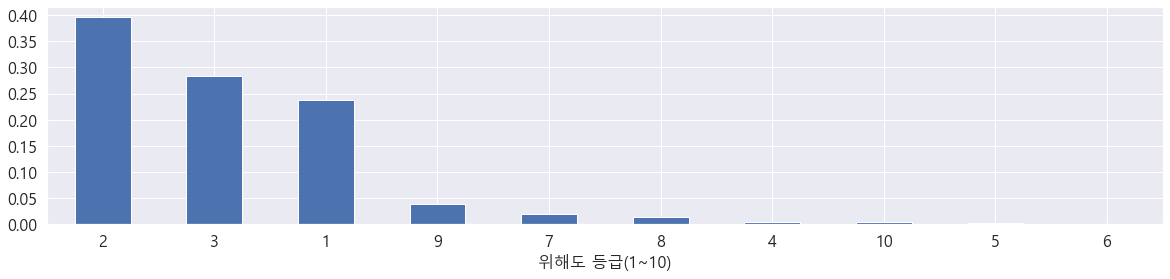

In [6]:
df['등급'].value_counts(normalize=True).plot(kind='bar', rot= 360, figsize=(20, 4))
plt.xlabel('위해도 등급(1~10)', fontsize=16)
plt.yticks(fontsize=16); plt.xticks(fontsize=16); 

<Figure size 864x720 with 0 Axes>

<AxesSubplot:xlabel='등급', ylabel='위해도점수'>

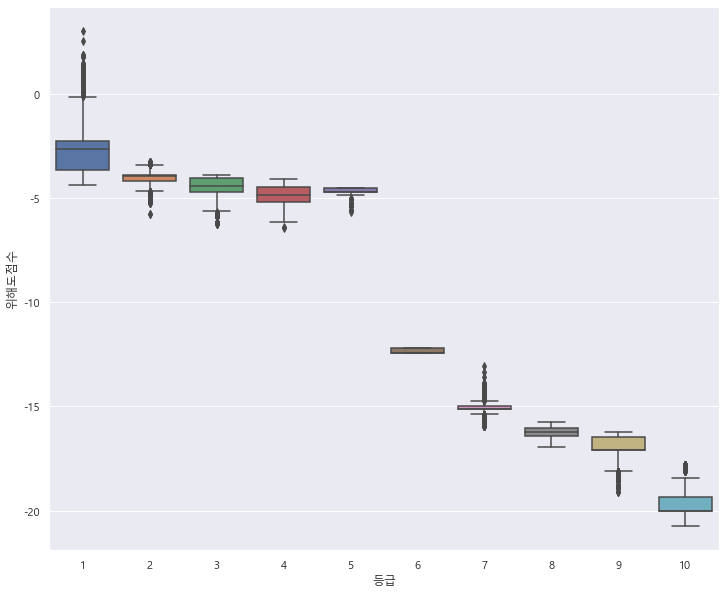

In [7]:
plt.figure(figsize = (12, 10))
sns.boxplot(df['등급'], np.log(df['위해도점수']))

In [8]:
(df.groupby('등급')['위해도점수'].count()/len(df)).cumsum()

등급
1     0.238450
2     0.634377
3     0.917050
4     0.921567
5     0.923302
6     0.923412
7     0.943384
8     0.957606
9     0.995815
10    1.000000
Name: 위해도점수, dtype: float64

<AxesSubplot:xlabel='등급'>

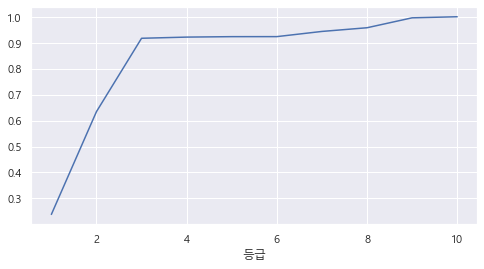

In [9]:
(df.groupby('등급')['위해도점수'].count()/len(df)).cumsum().plot(rot= 360, figsize=(8, 4))

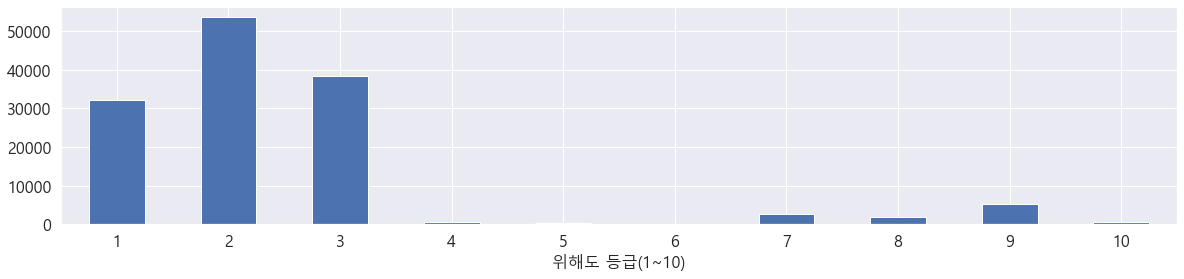

In [10]:
df.groupby('등급')['위해도점수'].count().plot(kind='bar', rot= 360, figsize=(20, 4))
plt.xlabel('위해도 등급(1~10)', fontsize=16)
plt.yticks(fontsize=16); plt.xticks(fontsize=16); 

In [11]:
len(df)
len(df)*0.04 # 4% 정밀검사
df['등급'].value_counts().sort_index()

135492

5419.68

1     32308
2     53645
3     38300
4       612
5       235
6        15
7      2706
8      1927
9      5177
10      567
Name: 등급, dtype: int64

In [12]:
df['위해도점수'].mean()

0.03727048072812348

In [13]:
pd.pivot_table(df, index=['등급'], columns=['부적합여부'], aggfunc=['count']).fillna(0)

count                                                                \
        국가명             년월          위해도점수           접수번호          제품명(한글)   
부적합여부   부적합       적합   부적합       적합   부적합       적합   부적합       적합     부적합   
등급                                                                          
1      31.0  32277.0  31.0  32277.0  31.0  32277.0  31.0  32277.0    31.0   
2      13.0  53632.0  13.0  53632.0  13.0  53632.0  13.0  53632.0    13.0   
3       8.0  38292.0   8.0  38292.0   8.0  38292.0   8.0  38292.0     8.0   
4       0.0    612.0   0.0    612.0   0.0    612.0   0.0    612.0     0.0   
5       0.0    235.0   0.0    235.0   0.0    235.0   0.0    235.0     0.0   
6       0.0     15.0   0.0     15.0   0.0     15.0   0.0     15.0     0.0   
7       0.0   2706.0   0.0   2706.0   0.0   2706.0   0.0   2706.0     0.0   
8       0.0   1927.0   0.0   1927.0   0.0   1927.0   0.0   1927.0     0.0   
9       0.0   5177.0   0.0   5177.0   0.0   5177.0   0.0   5177.0     0.0   
10      0.0    567.0   0.0    567.0   0.0    567.0   0.0    567.0     0.0   

                
                
부적합여부       적합  
등급              
1      32277.0  
2      53632.0  
3      38292.0  
4        612.0  
5        235.0  
6         15.0  
7       2706.0  
8       1927.0  
9       5177.0  
10       567.0

In [17]:
df['부적합여부'].value_counts()

적합     135440
부적합        52
Name: 부적합여부, dtype: int64

In [ ]:
fig = plt.figure(figsize=(15,6))
ax=sns.histplot(df.loc[(df['위험판정'] == 1), '위험점수'], color='red', label='정밀검사_판정(식약처 모형)')
ax=sns.histplot(df.loc[(df['위험판정'] == 0), '위험점수'], color='blue', label='수입통관(식약처 모형)')
plt.title('식약처 모형의 예측확률 판정분포', fontsize = 20)
plt.xticks(fontsize = 16); plt.xlabel('식약처모형 위험점수', fontsize = 16)
plt.legend()

<AxesSubplot:>

적합     99.961621
부적합     0.038379
Name: 부적합여부, dtype: float64

적합     135440
부적합        52
Name: 부적합여부, dtype: int64

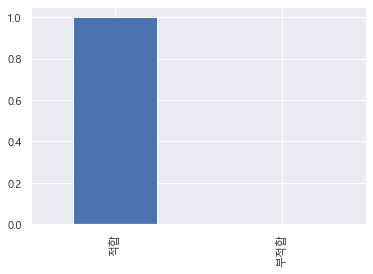

In [15]:
df['부적합여부'].value_counts(normalize=True).plot(kind='bar')
df['부적합여부'].value_counts(normalize=True)*100
df['부적합여부'].value_counts()

In [14]:
df[df['부적합여부'] != '적합'].sample(10)

,년월,접수번호,국가명,제품명(한글),위해도점수,등급,부적합여부
91375,202007,202000393990,대만,"눈다랑어(냉동,필렛(F),횟감)",0.232067,1,부적합
71900,202007,202000411670,미국,"명태(냉동,곤이)",0.012238,2,부적합
66699,202011,202000620974,알제리,냉동 참다랑어 볼살(횟감),0.074799,1,부적합
74949,202105,202100307227,중국,냉동황새치목살(횟감용),0.099064,1,부적합
68986,202011,202000665355,모로코,냉동절단갈치,0.079533,1,부적합
7231,202007,202000408871,미국,"명태(냉동,곤이)",0.012238,2,부적합
117259,202009,202000521230,파키스탄,냉동점박이절단게,0.012238,3,부적합
54359,202103,202100187821,프랑스,냉동참다랑어볼살횟감,0.033255,1,부적합
31985,202005,202000264891,인도,"냉동흰다리새우살(탈각,꼬리유)",0.019767,2,부적합
111058,202012,202000673431,일본,가리비(활),0.017550,3,부적합


In [15]:
df[df['부적합여부'] != '적합']['등급'].value_counts()
df[df['부적합여부'] == '적합']['등급'].value_counts()

1    31
2    13
3     8
Name: 등급, dtype: int64

2     53632
3     38292
1     32277
9      5177
7      2706
8      1927
4       612
10      567
5       235
6        15
Name: 등급, dtype: int64

In [16]:
df[df['부적합여부'] != '적합']['위해도점수'].min()

0.004989246

<AxesSubplot:ylabel='위해도점수'>

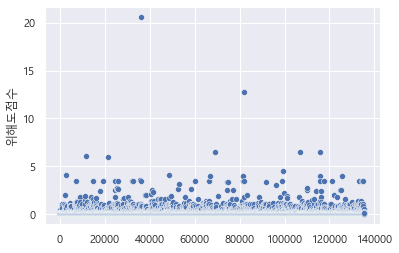

In [17]:
sns.scatterplot(np.arange(len(df)), df['위해도점수'])

<Figure size 2160x720 with 0 Axes>

Text(0.5, 1.0, '수산물 수입신고건수별(20.01 ~ 21.05) 위해도점수(0~100)')

Text(0.5, 0, '수산물 수입신고건_일별')

(array([-5.,  0.,  5., 10., 15., 20., 25.]),
 [Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, '')])

(array([-20000.,      0.,  20000.,  40000.,  60000.,  80000., 100000.,
        120000., 140000., 160000.]),
 [Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, '')])

Text(0, 0.5, '수산물 수입신고의 위해도 점수')

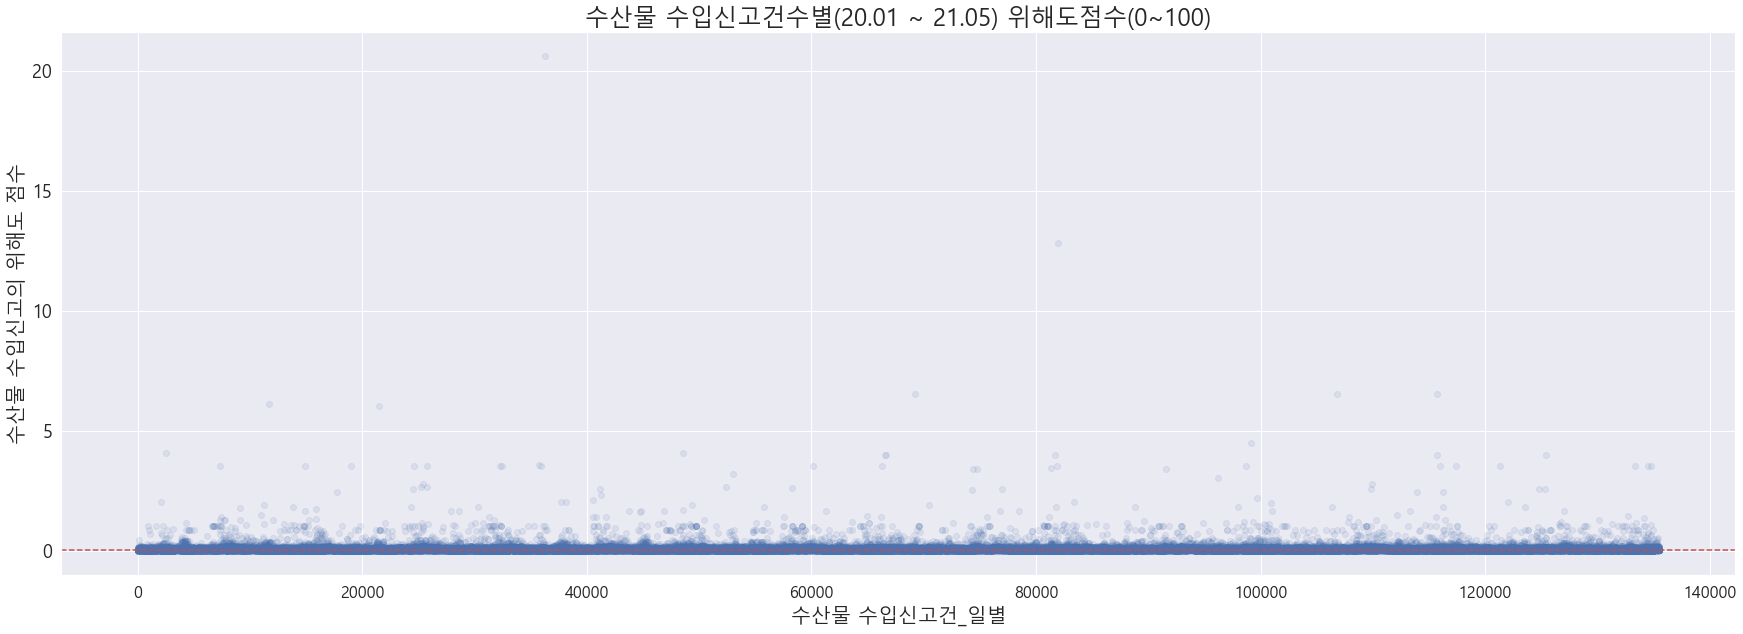

In [18]:
plt.figure(figsize=(30, 10))
plt.scatter(np.arange(df.shape[0]), df['위해도점수'].values, alpha=0.1)
plt.axhline(y=df['위해도점수'].mean(), color='r', linestyle='--')
plt.title('수산물 수입신고건수별(20.01 ~ 21.05) 위해도점수(0~100)', fontsize=24)
plt.xlabel('수산물 수입신고건_일별', fontsize=20)
plt.yticks(fontsize=18); plt.xticks(fontsize=16); 
plt.ylabel('수산물 수입신고의 위해도 점수', fontsize=20)

In [19]:
df.부적합여부.value_counts()
df.등급.value_counts()
df

적합     135440
부적합        52
Name: 부적합여부, dtype: int64

2     53645
3     38300
1     32308
9      5177
7      2706
8      1927
4       612
10      567
5       235
6        15
Name: 등급, dtype: int64

,년월,접수번호,국가명,제품명(한글),위해도점수,등급,부적합여부
0,202105,202100279576,러시아,대게(활),2.121335e-02,2,적합
1,202105,202100324697,중국,마른다시마,6.700000e-08,9,적합
2,202105,202100318343,노르웨이,연어(냉장),2.121335e-02,2,적합
3,202105,202100281302,러시아,냉동임연수어,2.899931e-02,2,적합
4,202105,202100319831,미국,바닷가재(활),9.668111e-02,1,적합
...,...,...,...,...,...,...,...
135487,202003,202000123325,중국,냉동절단꽃게,1.964075e-02,2,적합
135488,202003,202000137334,칠레,냉동태평양은연어,2.590053e-02,1,적합
135489,202003,202000114859,중국,활바지락,1.964075e-02,2,적합
135490,202003,202000144202,중국,활돌가자미,2.590053e-02,1,적합


In [20]:
df['안전도점수'] = 100 - df['위해도점수']
df

,년월,접수번호,국가명,제품명(한글),위해도점수,등급,부적합여부,안전도점수
0,202105,202100279576,러시아,대게(활),2.121335e-02,2,적합,99.978787
1,202105,202100324697,중국,마른다시마,6.700000e-08,9,적합,100.000000
2,202105,202100318343,노르웨이,연어(냉장),2.121335e-02,2,적합,99.978787
3,202105,202100281302,러시아,냉동임연수어,2.899931e-02,2,적합,99.971001
4,202105,202100319831,미국,바닷가재(활),9.668111e-02,1,적합,99.903319
...,...,...,...,...,...,...,...,...
135487,202003,202000123325,중국,냉동절단꽃게,1.964075e-02,2,적합,99.980359
135488,202003,202000137334,칠레,냉동태평양은연어,2.590053e-02,1,적합,99.974099
135489,202003,202000114859,중국,활바지락,1.964075e-02,2,적합,99.980359
135490,202003,202000144202,중국,활돌가자미,2.590053e-02,1,적합,99.974099


In [21]:
df['y_test'] = df.부적합여부.replace({'적합' : 0, '부적합':1})
df

,년월,접수번호,국가명,제품명(한글),위해도점수,등급,부적합여부,안전도점수,y_test
0,202105,202100279576,러시아,대게(활),2.121335e-02,2,적합,99.978787,0
1,202105,202100324697,중국,마른다시마,6.700000e-08,9,적합,100.000000,0
2,202105,202100318343,노르웨이,연어(냉장),2.121335e-02,2,적합,99.978787,0
3,202105,202100281302,러시아,냉동임연수어,2.899931e-02,2,적합,99.971001,0
4,202105,202100319831,미국,바닷가재(활),9.668111e-02,1,적합,99.903319,0
...,...,...,...,...,...,...,...,...,...
135487,202003,202000123325,중국,냉동절단꽃게,1.964075e-02,2,적합,99.980359,0
135488,202003,202000137334,칠레,냉동태평양은연어,2.590053e-02,1,적합,99.974099,0
135489,202003,202000114859,중국,활바지락,1.964075e-02,2,적합,99.980359,0
135490,202003,202000144202,중국,활돌가자미,2.590053e-02,1,적합,99.974099,0


In [38]:
df['부적합여부'].value_counts()

적합     135440
부적합        52
Name: 부적합여부, dtype: int64

In [22]:
df['위해도점수'].mean()
df['위해도점수'].skew()

0.03727048072812348

52.08999965843837

In [23]:
y_test = df['y_test']
y_probas = df[['안전도점수', '위해도점수']].values
y_test
y_probas

0         0
1         0
2         0
3         0
4         0
         ..
135487    0
135488    0
135489    0
135490    0
135491    0
Name: y_test, Length: 135492, dtype: int64

array([[9.99787866e+01, 2.12133530e-02],
       [9.99999999e+01, 6.70000000e-08],
       [9.99787866e+01, 2.12133530e-02],
       ...,
       [9.99803592e+01, 1.96407540e-02],
       [9.99740995e+01, 2.59005310e-02],
       [9.98403743e+01, 1.59625660e-01]])

In [24]:
from sklearn.metrics import precision_recall_curve
def to_labels(pos_probs, threshold):
    return (pos_probs >= threshold).astype('int')
p, r, thresholds = precision_recall_curve(y_test, y_probas[:, 1])
scores = [np.sum(to_labels(y_probas[:, 1], t))/len(y_probas[:, 1]) for t in thresholds]

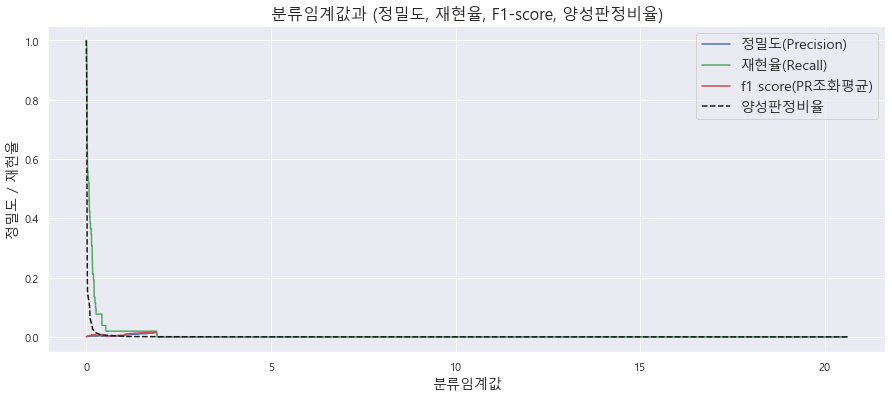

In [25]:
def plot_precision_recall_vs_threshold(precisions, recalls, thresholds):
    plt.rcParams["figure.figsize"] = (15,6)
    plt.rcParams['font.family']='Malgun Gothic' # 한글폰트
    plt.title('분류임계값과 (정밀도, 재현율, F1-score, 양성판정비율)', fontsize='16')
    plt.plot(thresholds, precisions[:-1], 'b-', label='정밀도(Precision)') # 판사
    plt.plot(thresholds, recalls[:-1], 'g-', label='재현율(Recall)') # 검사
    plt.plot(thresholds, (2*precisions[:-1]*recalls[:-1])/(precisions[:-1] +recalls[:-1]),
    'r-', label='f1 score(PR조화평균)') # 변호사
    plt.plot(thresholds, scores, 'k--', label='양성판정비율') # q-ratio
    plt.ylabel('정밀도 / 재현율', fontsize='14')
    plt.xlabel('분류임계값', fontsize='14')
    plt.legend(loc='best', fontsize='14')
plot_precision_recall_vs_threshold(p, r, thresholds)

### 식약처의 위해도 예측모형의 판정여부는 알수가 없음
- 부적합여부는 실제 판정결과인 y_test 값과 동일함

In [36]:
 y_pred = df.replace({'부적합여부': {'적합': 0, '부적합': 1}})['부적합여부']

array([[135440,      0],
       [     0,     52]], dtype=int64)

<AxesSubplot:>

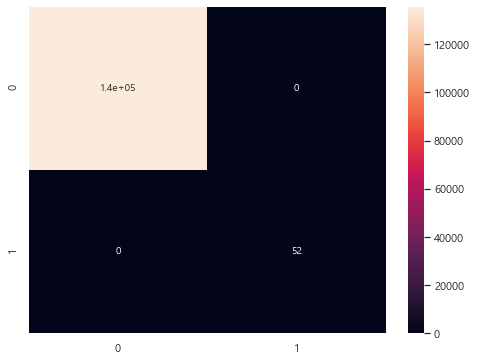

In [37]:
from sklearn.metrics import confusion_matrix, classification_report
plt.rcParams["figure.figsize"] = (8,6)
confusion_matrix(y_test, y_pred)
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True)

<AxesSubplot:title={'center':'ROC Curves'}, xlabel='False Positive Rate', ylabel='True Positive Rate'>

<AxesSubplot:title={'center':'Precision-Recall Curve'}, xlabel='Recall', ylabel='Precision'>

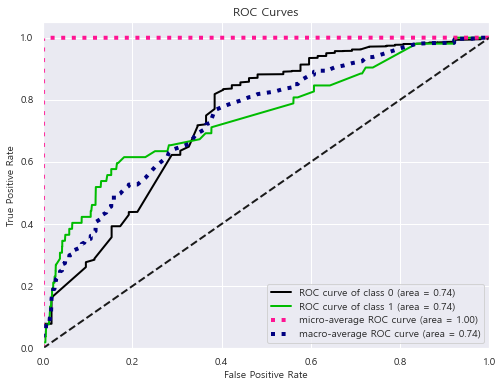

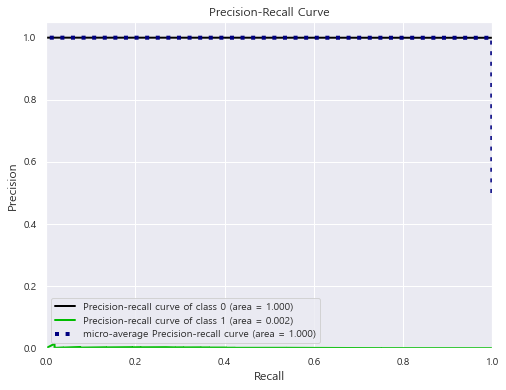

In [44]:
import scikitplot as skplt 
skplt.metrics.plot_roc(y_test, y_probas)
skplt.metrics.plot_precision_recall(y_test, y_probas)

<AxesSubplot:title={'center':'Lift Curve'}, xlabel='Percentage of sample', ylabel='Lift'>

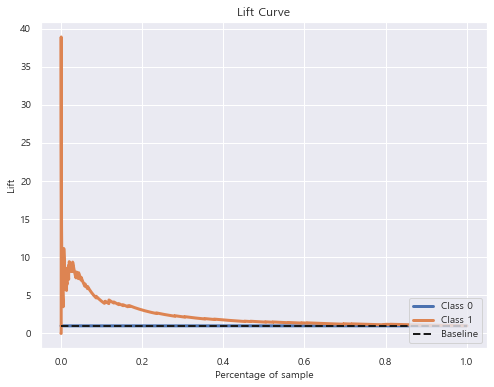

<AxesSubplot:title={'center':'Cumulative Gains Curve'}, xlabel='Percentage of sample', ylabel='Gain'>

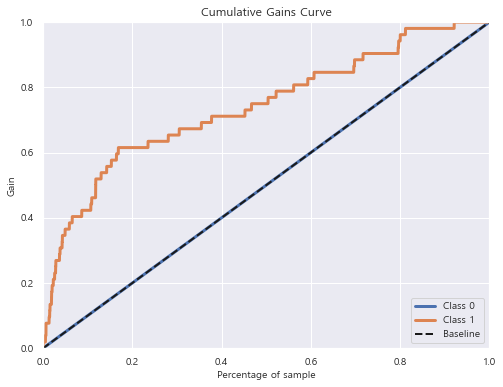

In [46]:
skplt.metrics.plot_lift_curve(y_test, y_probas); plt.show()
skplt.metrics.plot_cumulative_gain(y_test, y_probas)

# New 위해도 모형

In [26]:
new = np.abs(np.random.randn(len(np.arange(df.shape[0]))))

<Figure size 2160x720 with 0 Axes>

Text(0.5, 1.0, '수산물 수입신고건수별(20.01 ~ 21.05) 위해도점수(0~100)')

Text(0.5, 0, '수산물 수입신고건_일별')

(array([-1.,  0.,  1.,  2.,  3.,  4.,  5.]),
 [Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, '')])

(array([-20000.,      0.,  20000.,  40000.,  60000.,  80000., 100000.,
        120000., 140000., 160000.]),
 [Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, '')])

Text(0, 0.5, '수산물 수입신고의 위해도 점수')

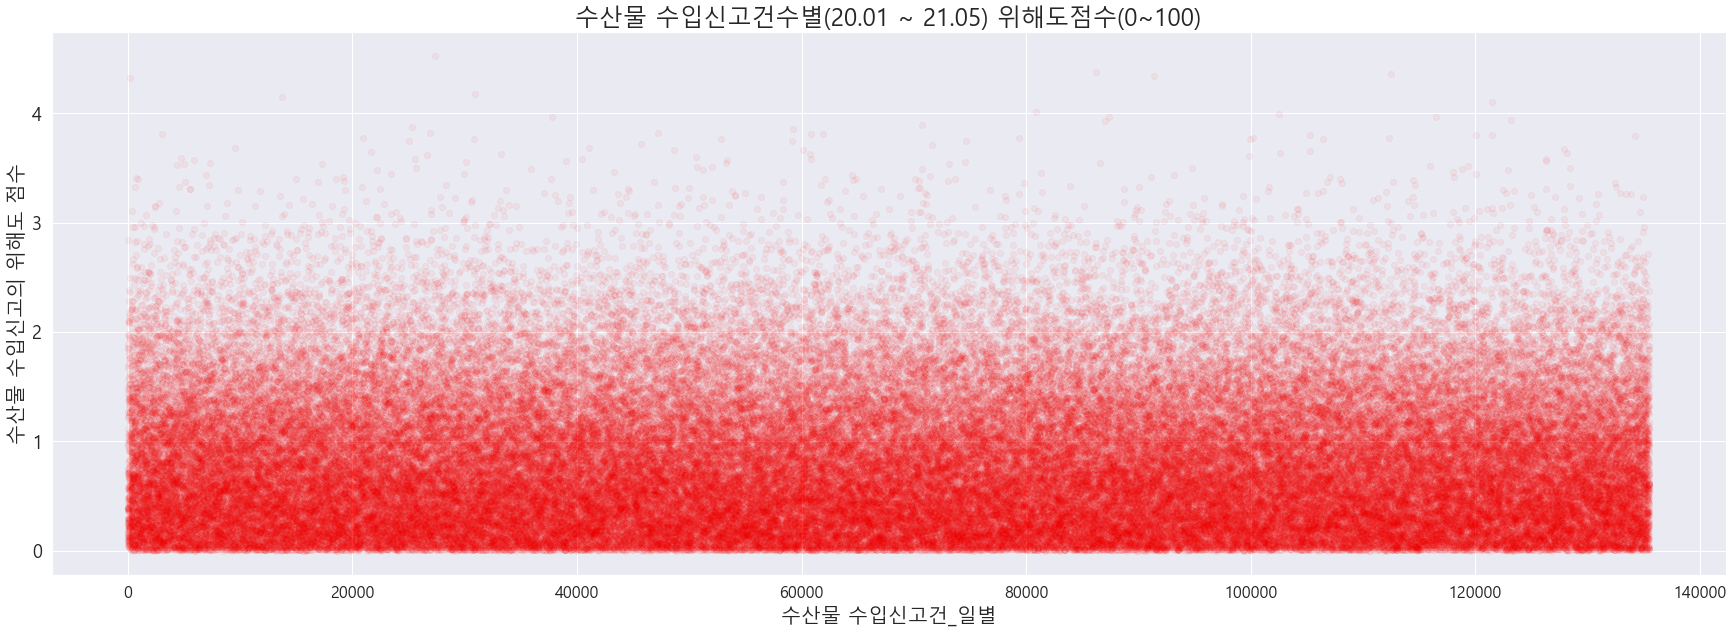

In [27]:
plt.figure(figsize=(30, 10))
plt.scatter(np.arange(df.shape[0]), new, alpha=0.05, color='red')
plt.title('수산물 수입신고건수별(20.01 ~ 21.05) 위해도점수(0~100)', fontsize=24)
plt.xlabel('수산물 수입신고건_일별', fontsize=20)
plt.yticks(fontsize=18); plt.xticks(fontsize=16); 
plt.ylabel('수산물 수입신고의 위해도 점수', fontsize=20)

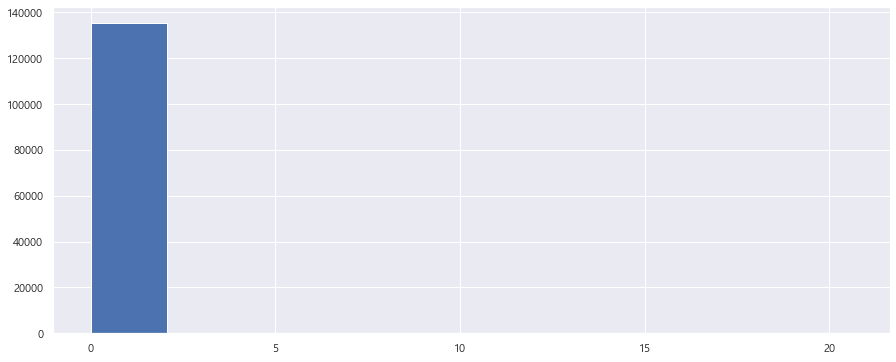

In [28]:
ax = plt.hist(df['위해도점수'])

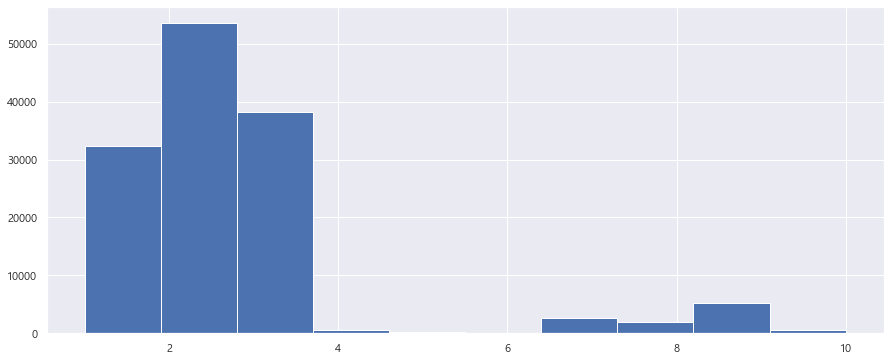

In [29]:
ax = plt.hist(df['등급'])

<Figure size 1800x216 with 0 Axes>

최고 위해도 점수 20.604451528, 최저 위해도 점수 0.0


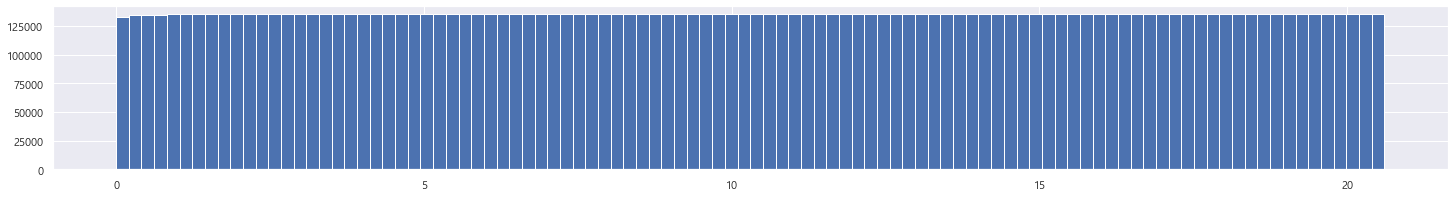

In [30]:
plt.figure(figsize=(25, 3)); 
ax = plt.hist(df['위해도점수'], bins = 100, cumulative=True)
max = df['위해도점수'].max(); min = df['위해도점수'].min()
print(f'최고 위해도 점수 {max}, 최저 위해도 점수 {min}')

(-0.1, 20.704451528)

(-0.1, 1.5)

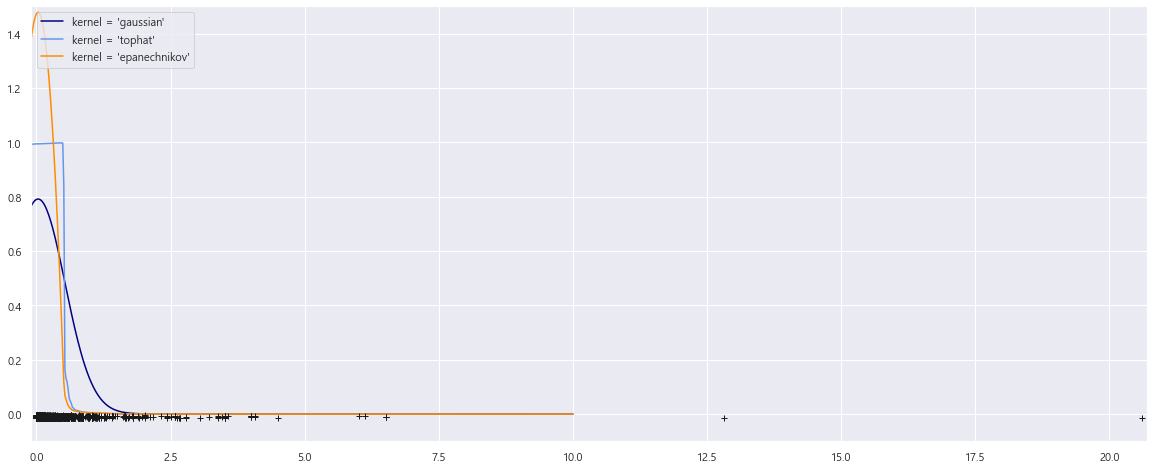

In [31]:
from sklearn.neighbors import KernelDensity
from scipy.stats import norm

X = df['위해도점수'].values.reshape(-1,1)
X_plot = np.linspace(-10, 10, 1000)[:, np.newaxis]

fig, ax = plt.subplots(figsize=(20, 8))

colors = ['navy', 'cornflowerblue', 'darkorange']; kernels = ['gaussian', 'tophat', 'epanechnikov']

for color, kernel in zip(colors, kernels):
    kde = KernelDensity(kernel=kernel, bandwidth=0.5).fit(X)
    log_dens = kde.score_samples(X_plot)
    ax.plot(X_plot[:, 0], np.exp(log_dens), color=color, linestyle='-', label="kernel = '{0}'".format(kernel))

ax.legend(loc='upper left')
ax.plot(X[:, 0], -0.005 - 0.01 * np.random.random(X.shape[0]), '+k')
ax.set_xlim(df['위해도점수'].min()-0.1, df['위해도점수'].max()+0.1); ax.set_ylim(-0.1, 1.5)
plt.show()

# End